In [60]:
from autots import AutoTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Analysis & Preprocessing 

## Tasks
#### 1. Load the dataset
#### 2. Convert dates and clean data using appropriate pre-processing techniques
#### 3. Explore the time-series data using visualizations and correlation plots

In [61]:
#loading data
df = pd.read_csv("Foreign_Exchange_Rates.xls")
df.head()

,Unnamed: 0,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,...,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$,Unnamed: 24
0,0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,...,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97,NaN
1,1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,...,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13,NaN
2,2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,...,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1,NaN
3,3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,...,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62,NaN
4,4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,...,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3,NaN


### Preprocessing

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Unnamed: 0                                 5217 non-null   int64  
 1   Time Serie                                 5217 non-null   object 
 2   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object 
 3   EURO AREA - EURO/US$                       5217 non-null   object 
 4   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object 
 5   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object 
 6   BRAZIL - REAL/US$                          5217 non-null   object 
 7   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object 
 8   CHINA - YUAN/US$                           5217 non-null   object 
 9   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object 
 10  INDIA - INDIAN RUPEE/US$

In [63]:
#Checking for missing values 
print('\nMissing Values:')
print(df.isnull().sum()) 


Missing Values:
Unnamed: 0                                      0
Time Serie                                      0
AUSTRALIA - AUSTRALIAN DOLLAR/US$               0
EURO AREA - EURO/US$                            0
NEW ZEALAND - NEW ZELAND DOLLAR/US$             0
UNITED KINGDOM - UNITED KINGDOM POUND/US$       0
BRAZIL - REAL/US$                               0
CANADA - CANADIAN DOLLAR/US$                    0
CHINA - YUAN/US$                                0
HONG KONG - HONG KONG DOLLAR/US$                0
INDIA - INDIAN RUPEE/US$                        0
KOREA - WON/US$                                 0
MEXICO - MEXICAN PESO/US$                       0
SOUTH AFRICA - RAND/US$                         0
SINGAPORE - SINGAPORE DOLLAR/US$                0
DENMARK - DANISH KRONE/US$                      0
JAPAN - YEN/US$                                 0
MALAYSIA - RINGGIT/US$                          0
NORWAY - NORWEGIAN KRONE/US$                    0
SWEDEN - KRONA/US$               

In [64]:
#dropping unneccessary columns and missing values
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 24'])
df.head()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,03-01-2000,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,04-01-2000,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,05-01-2000,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,06-01-2000,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,07-01-2000,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3


In [65]:
#dropping null values and converting timeseries to datetime 
df = df.dropna()
df['Time Serie'] = pd.to_datetime(df['Time Serie'], format='%d-%m-%Y')
df.head()

,Time Serie,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
0,2000-01-03,1.5172,0.9847,1.9033,0.6146,1.805,1.4465,8.2798,7.7765,43.55,...,1.6563,7.329,101.7,3.8,7.964,8.443,72.3,1.5808,31.38,36.97
1,2000-01-04,1.5239,0.97,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,...,1.6535,7.218,103.09,3.8,7.934,8.36,72.65,1.5565,30.6,37.13
2,2000-01-05,1.5267,0.9676,1.9339,0.6092,1.856,1.4518,8.2798,7.778,43.55,...,1.656,7.208,103.77,3.8,7.935,8.353,72.95,1.5526,30.8,37.1
3,2000-01-06,1.5291,0.9686,1.9436,0.607,1.84,1.4571,8.2797,7.7785,43.55,...,1.6655,7.2125,105.19,3.8,7.94,8.3675,72.95,1.554,31.75,37.62
4,2000-01-07,1.5272,0.9714,1.938,0.6104,1.831,1.4505,8.2794,7.7783,43.55,...,1.6625,7.2285,105.17,3.8,7.966,8.415,73.15,1.5623,30.85,37.3


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Time Serie                                 5217 non-null   datetime64[ns]
 1   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5217 non-null   object        
 2   EURO AREA - EURO/US$                       5217 non-null   object        
 3   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5217 non-null   object        
 4   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5217 non-null   object        
 5   BRAZIL - REAL/US$                          5217 non-null   object        
 6   CANADA - CANADIAN DOLLAR/US$               5217 non-null   object        
 7   CHINA - YUAN/US$                           5217 non-null   object        
 8   HONG KONG - HONG KONG DOLLAR/US$           5217 non-null   object        
 9   INDIA - INDIAN RUPE

In [67]:
#Time Serie column changed to datetime datatype 

In [68]:
#sorting time-series by time order 
df = df.sort_values('Time Serie')

In [69]:
# set time column as index 
df = df.set_index('Time Serie') 

In [70]:
#converting data in columns into numeric data (not object, str) 
df = df.apply(pd.to_numeric, errors='coerce')
#handling any new missing values 
df=df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5015 entries, 2000-01-03 to 2019-12-31
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   AUSTRALIA - AUSTRALIAN DOLLAR/US$          5015 non-null   float64
 1   EURO AREA - EURO/US$                       5015 non-null   float64
 2   NEW ZEALAND - NEW ZELAND DOLLAR/US$        5015 non-null   float64
 3   UNITED KINGDOM - UNITED KINGDOM POUND/US$  5015 non-null   float64
 4   BRAZIL - REAL/US$                          5015 non-null   float64
 5   CANADA - CANADIAN DOLLAR/US$               5015 non-null   float64
 6   CHINA - YUAN/US$                           5015 non-null   float64
 7   HONG KONG - HONG KONG DOLLAR/US$           5015 non-null   float64
 8   INDIA - INDIAN RUPEE/US$                   5015 non-null   float64
 9   KOREA - WON/US$                            5015 non-null   float64
 10  MEXICO

In [71]:
#data changed to float64 and 202 rows dropped

In [72]:
df.head()

,AUSTRALIA - AUSTRALIAN DOLLAR/US$,EURO AREA - EURO/US$,NEW ZEALAND - NEW ZELAND DOLLAR/US$,UNITED KINGDOM - UNITED KINGDOM POUND/US$,BRAZIL - REAL/US$,CANADA - CANADIAN DOLLAR/US$,CHINA - YUAN/US$,HONG KONG - HONG KONG DOLLAR/US$,INDIA - INDIAN RUPEE/US$,KOREA - WON/US$,...,SINGAPORE - SINGAPORE DOLLAR/US$,DENMARK - DANISH KRONE/US$,JAPAN - YEN/US$,MALAYSIA - RINGGIT/US$,NORWAY - NORWEGIAN KRONE/US$,SWEDEN - KRONA/US$,SRI LANKA - SRI LANKAN RUPEE/US$,SWITZERLAND - FRANC/US$,TAIWAN - NEW TAIWAN DOLLAR/US$,THAILAND - BAHT/US$
Time Serie,,,,,,,,,,,,,,,,,,,,,
2000-01-03,1.5172,0.9847,1.9033,0.6146,1.8050,1.4465,8.2798,7.7765,43.55,1128.0,...,1.6563,7.3290,101.70,3.8,7.964,8.4430,72.30,1.5808,31.38,36.97
2000-01-04,1.5239,0.9700,1.9238,0.6109,1.8405,1.4518,8.2799,7.7775,43.55,1122.5,...,1.6535,7.2180,103.09,3.8,7.934,8.3600,72.65,1.5565,30.60,37.13
2000-01-05,1.5267,0.9676,1.9339,0.6092,1.8560,1.4518,8.2798,7.7780,43.55,1135.0,...,1.6560,7.2080,103.77,3.8,7.935,8.3530,72.95,1.5526,30.80,37.10
2000-01-06,1.5291,0.9686,1.9436,0.6070,1.8400,1.4571,8.2797,7.7785,43.55,1146.5,...,1.6655,7.2125,105.19,3.8,7.940,8.3675,72.95,1.5540,31.75,37.62
2000-01-07,1.5272,0.9714,1.9380,0.6104,1.8310,1.4505,8.2794,7.7783,43.55,1138.0,...,1.6625,7.2285,105.17,3.8,7.966,8.4150,73.15,1.5623,30.85,37.30


### EDA

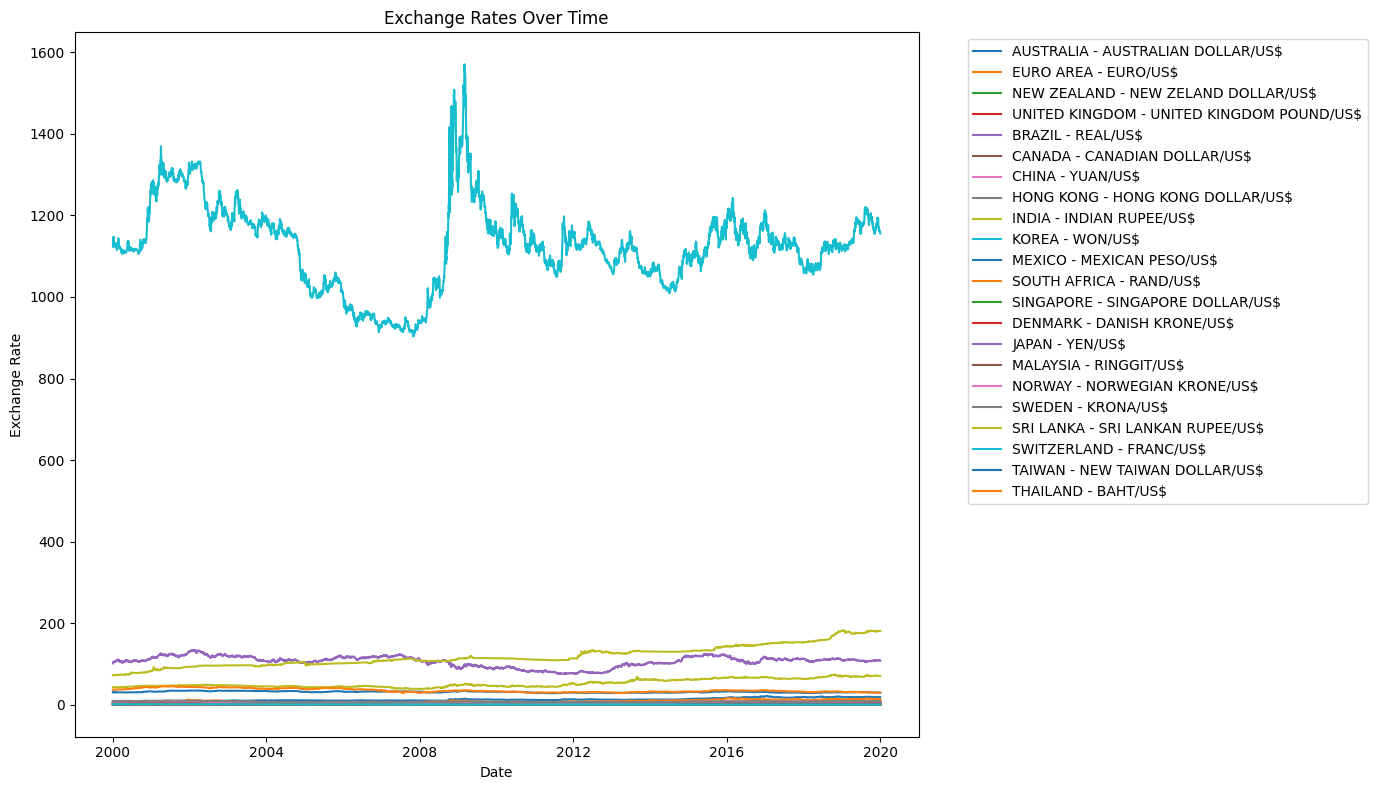

In [73]:
#line plot
plt.figure(figsize=(14,8))
for col in df.columns:
    plt.plot(df.index, df[col], label=col)

plt.title('Exchange Rates Over Time') 
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### analysis
1. biggest exchange rate is between Korea and US -> a lot of inflation in Korea
2. most exchange rates are quite low (0-200)
3. cannot see much flunctuations from this graph along -> make subplots

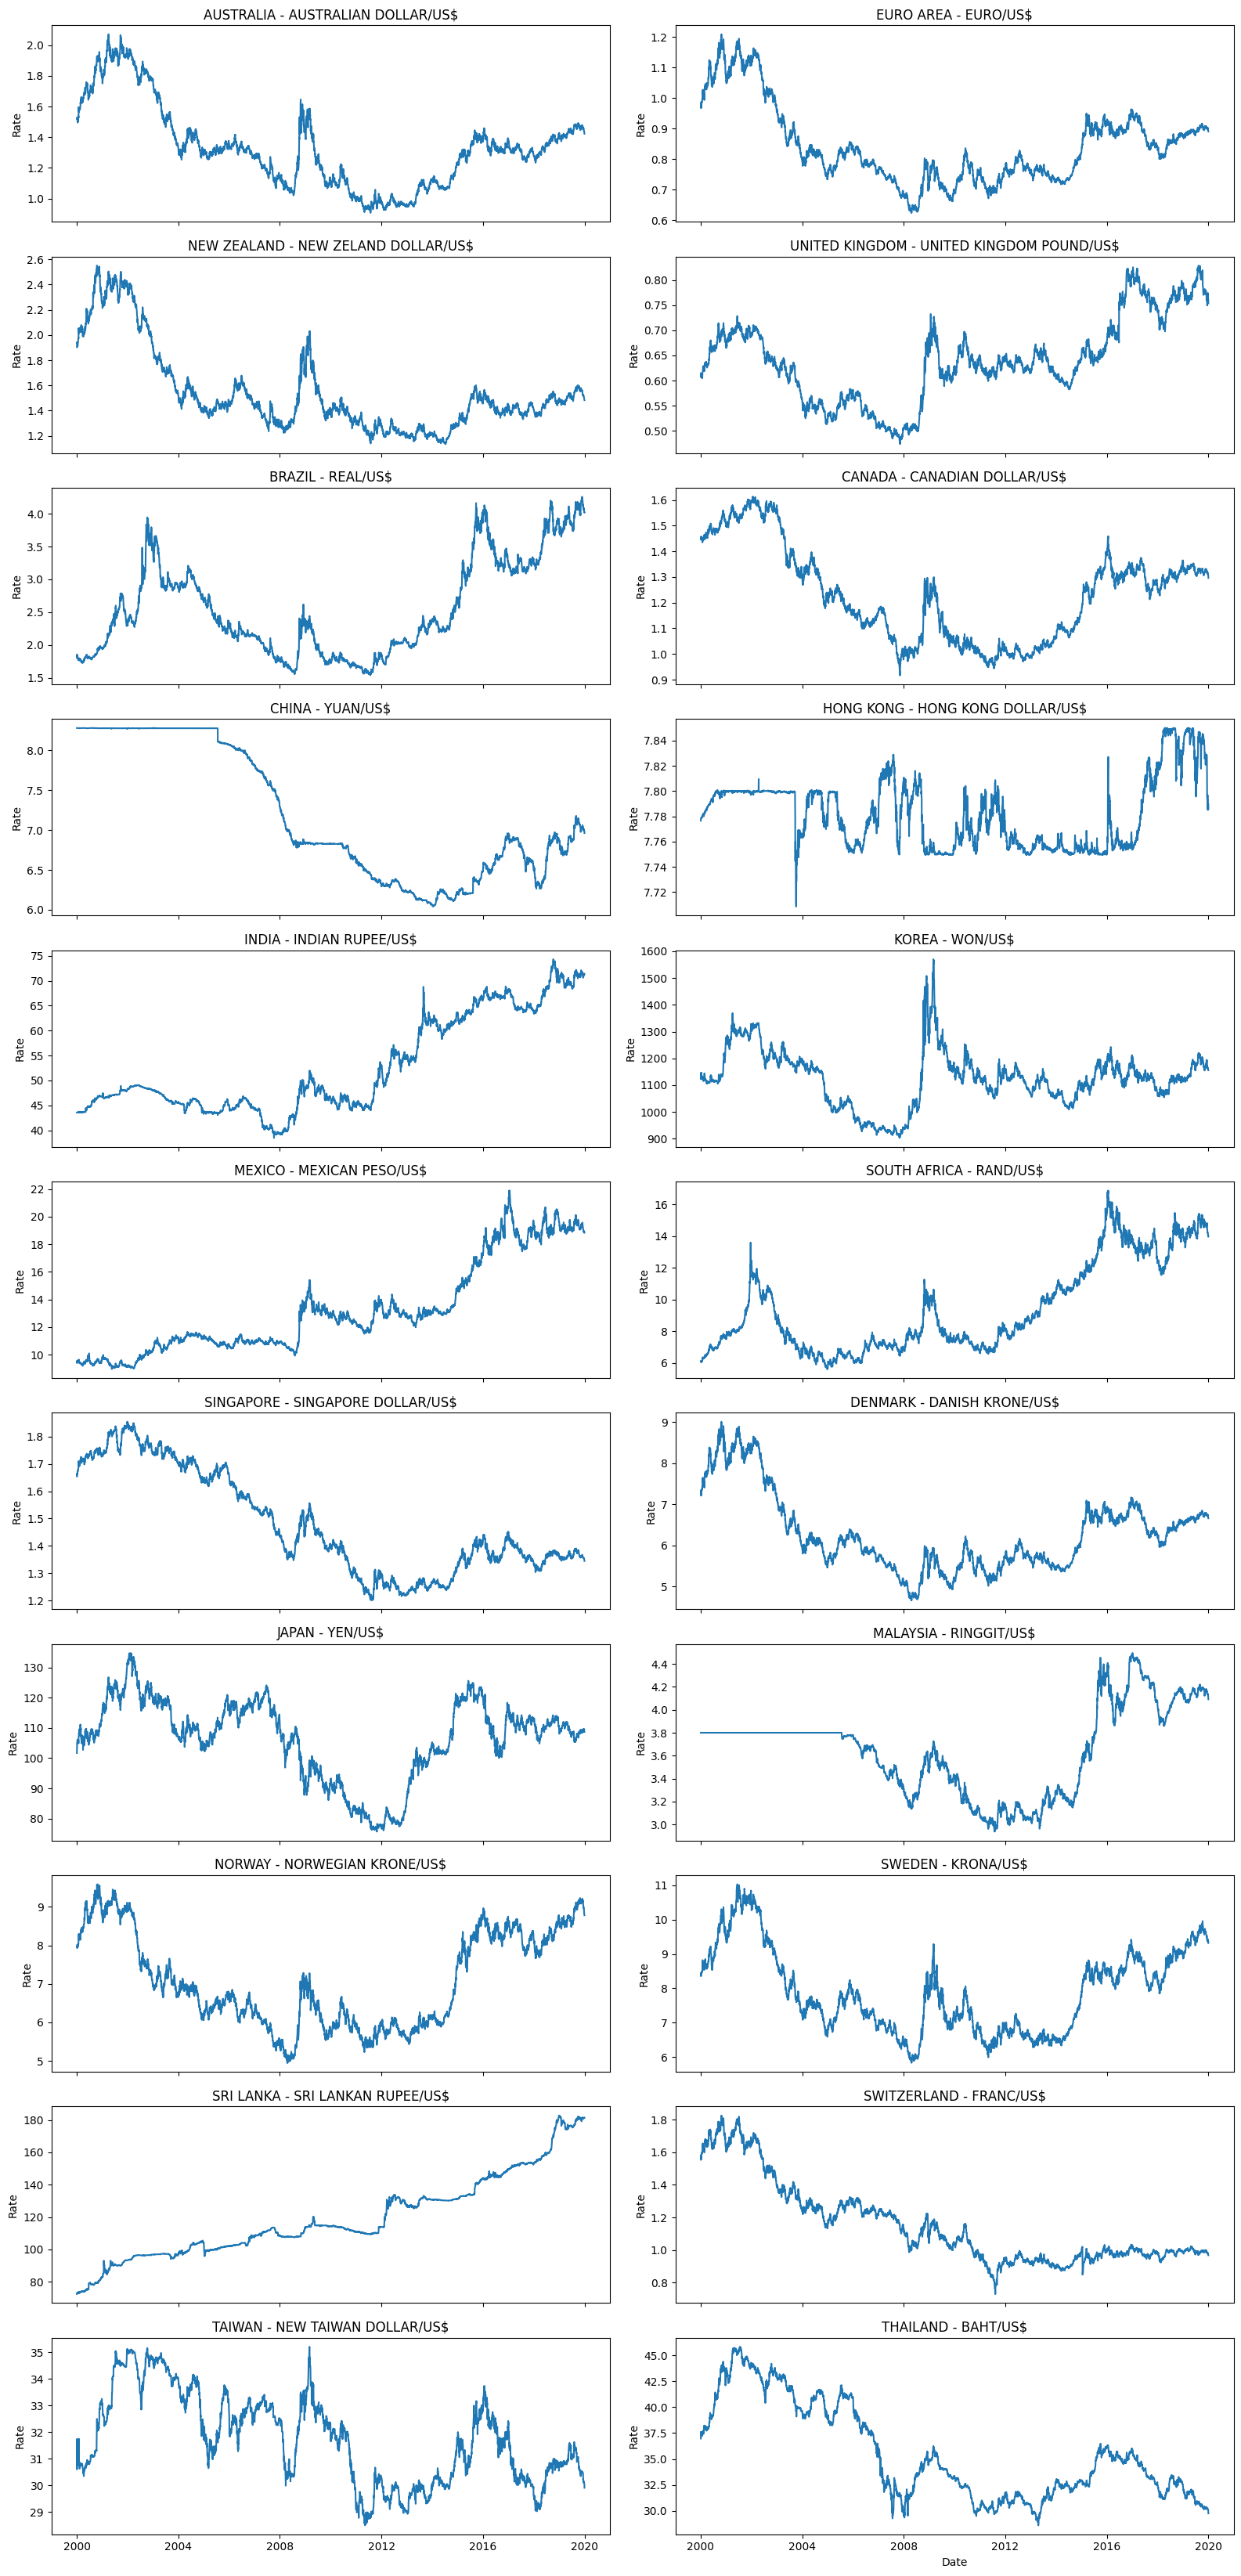

In [74]:
#making subplots
n_cols = 2 #2 columns
n_rows = 11 #11 rows 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows), sharex=True) #sharex = True: all subplots share the same time (x) axis

#making a plot for each exchange rate
for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i+1)
    plt.plot(df.index, df[col])
    plt.title(col)
    plt.ylabel("Rate")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

#### seeing for any trends / analysis
1. Sri Lanka Rupee -> US exchange rate is going up over the years (not much decrease)
2. in a lot of countries, the exchange rate seems to be decreasing/stays relatively low between 2008-2016 before increasing again
3. there are a lot of fluctuations

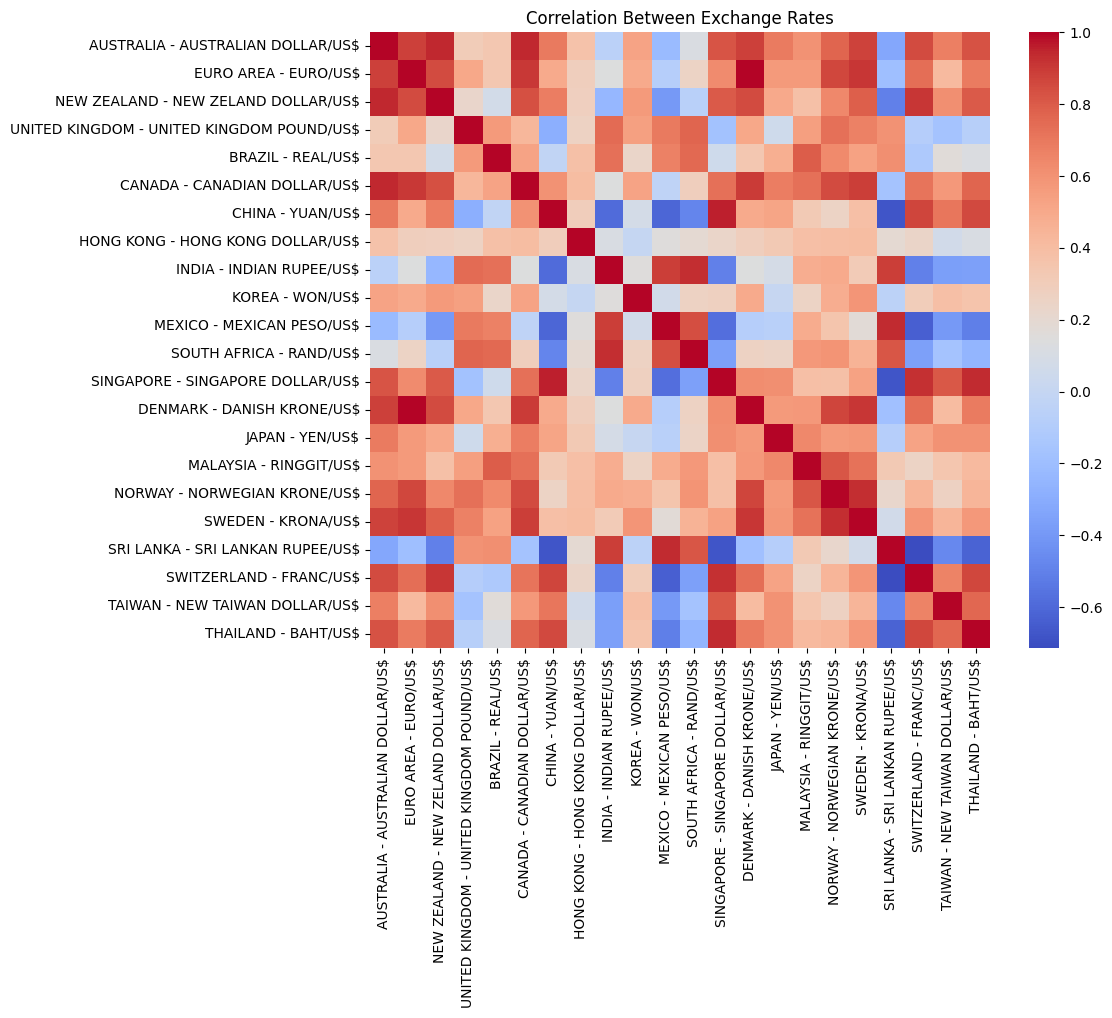

In [75]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Between Exchange Rates")
plt.show()

#### analysis
1. most exchange rates are positively correlated (there are many red/orange cells)
-> this suggests that many currencies move together against the US dollar (US dollar is more than country currency)
-> there is a strong global component driving exchange rate movements
2. there are strong positive correlations between currencies in European and developed countries against US (similar responses to USD exchange)
3. some countries such as Sri Lankan Rupee, Korean Won, Mexican Peso have lower correlations and show some negative correlations with certain developed countries (eg. China, Singapore for Sri Lanka)

# Predictive Modeling

Your goal is to compare several time-series forecasting models and pick the best one for each currency.

Model Suggestions:
1. XGBoost / LightGBM – can work with time features
2. LSTM – deep learning approach for sequential data
3. AutoTS – automates model selection
4. ARIMA / SARIMA – statistical modeling
5. Prophet – handles trends and seasonality well

For each model:

1. Split your data into train and test (e.g., last 60 days as test)
2. Train and evaluate each model
3. Compare metrics: MAE, RMSE, MAPE

In [76]:
#selecting currency 

options = {
    'AUSTRALIAN DOLLAR': 'AUSTRALIA - AUSTRALIAN DOLLAR/US$',
    'EURO': 'EURO AREA - EURO/US$',
    'NEW ZEALAND DOLLAR': 'NEW ZEALAND - NEW ZEALAND DOLLAR/US$',
    'GREAT BRITAIN POUNDS': 'UNITED KINGDOM - UNITED KINGDOM POUND/US$',
    'BRAZILIAN REAL': 'BRAZIL - REAL/US$',
    'CANADIAN DOLLAR': 'CANADA - CANADIAN DOLLAR/US$',
    'CHINESE YUAN$': 'CHINA - YUAN/US$',
    'HONG KONG DOLLAR': 'HONG KONG - HONG KONG DOLLAR/US$',
    'INDIAN RUPEE': 'INDIA - INDIAN RUPEE/US$',
    'KOREAN WON$': 'KOREA - WON/US$',
    'MEXICAN PESO': 'MEXICO - MEXICAN PESO/US$',
    'SOUTH AFRICAN RAND$': 'SOUTH AFRICA - RAND/US$',
    'SINGAPORE DOLLAR': 'SINGAPORE - SINGAPORE DOLLAR/US$',
    'DANISH KRONE': 'DENMARK - DANISH KRONE/US$',
    'JAPANESE YEN$': 'JAPAN - YEN/US$',
    'MALAYSIAN RINGGIT': 'MALAYSIA - RINGGIT/US$',
    'NORWEGIAN KRONE': 'NORWAY - NORWEGIAN KRONE/US$',
    'SWEDEN KRONA': 'SWEDEN - KRONA/US$',
    'SRILANKAN RUPEE': 'SRI LANKA - SRI LANKAN RUPEE/US$',
    'SWISS FRANC': 'SWITZERLAND - FRANC/US$',
    'NEW TAIWAN DOLLAR': 'TAIWAN - NEW TAIWAN DOLLAR/US$',
    'THAI BAHT': 'THAILAND - BAHT/US$'
}

selected_option = 'SRILANKAN RUPEE' #select currency here to train model

## LSTM

In [77]:
#selecting the currency series 
currency_col = options[selected_option] #selects the column name for chosen currency 
series = df[currency_col] #extract the selected currency as a Pandas series

In [78]:
#train/test split with validation 
total_rows = len(series)
train_end = int(0.7*total_rows)
val_end = int(0.8*total_rows)

#data split: train=70%, val=10%, test=20%

train_series = series.iloc[0:train_end] 
val_series = series.iloc[train_end:val_end] 
test_series = series.iloc[val_end:] 

In [79]:
train_series.shape, val_series.shape, test_series.shape

((3510,), (502,), (1003,))

In [80]:
#scaling the data 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(train_series.values.reshape(-1,1))
val_scaled   = scaler.transform(val_series.values.reshape(-1,1))
test_scaled  = scaler.transform(test_series.values.reshape(-1,1))

In [81]:
def Sequential_Input_LSTM(scaled_df, window):
    X = []
    y = []

    for i in range(len(scaled_df) - window):
        row = [a for a in scaled_df[i:i+window]] #includes all values from the window size (eg. values from 1-60)
        X.append(row)
        label = scaled_df[i + window] #value of the next one after window size (eg. 61st value)
        y.append(label)

    return np.array(X), np.array(y)

#for dataset, last 60 days
#X_train, X_val, X_test = number of sliding sequences
#Number of sequences = rows in segment – n_input
n_input = 60
X_train, y_train = Sequential_Input_LSTM(pd.Series(train_scaled.flatten()), n_input)
X_val, y_val     = Sequential_Input_LSTM(pd.Series(val_scaled.flatten()), n_input)
X_test, y_test   = Sequential_Input_LSTM(pd.Series(test_scaled.flatten()), n_input)

In [82]:
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

X_train: (3450, 60)
X_val:   (442, 60)
X_test:  (943, 60)


In [83]:
#create TensorFlow model 

#importing libraries needed for building the model
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import * #using LSTM model 
from tensorflow.keras.callbacks import EarlyStopping #to monitor the loss and stop if there is no change in loss
from tensorflow.keras.losses import MeanSquaredError 
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam 

In [84]:
n_features = 1  # number of input variables used prediction

model = Sequential()

model.add(InputLayer((n_input,n_features))) #input layer, n_input = number of historical input, n_features = number of features
#add two LSTM layers with 100 units each
model.add(LSTM(100, return_sequences = True))     
model.add(LSTM(100, return_sequences = True))
model.add(LSTM(50)) #another LSTM layer with 50 units 
model.add(Dense(8, activation = 'relu')) #two dense/fully connected layers 
model.add(Dense(1, activation = 'linear')) #regression forecasting

model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_69 (LSTM)                       │ (None, 60, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_70 (LSTM)                       │ (None, 60, 100)             │          80,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_71 (LSTM)                       │ (None, 50)                  │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_46 (Dense)                     │ (None, 8)                   │             408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_47 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,817 (593.04 KB)

 Trainable params: 151,817 (593.04 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
early_stop = EarlyStopping(monitor = 'val_loss', patience = 2) #if no change in 2 epoches in validation loss -> model stops training

#compile using root mean squared error 
model.compile(loss = MeanSquaredError(), optimizer = Adam(learning_rate = 0.0001), metrics = [RootMeanSquaredError()])

In [86]:
model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 50,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 99ms/step - loss: 0.0391 - root_mean_squared_error: 0.1978 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0593
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 5.6675e-04 - root_mean_squared_error: 0.0238 - val_loss: 5.5567e-04 - val_root_mean_squared_error: 0.0236
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 3.9726e-04 - root_mean_squared_error: 0.0199 - val_loss: 4.5946e-04 - val_root_mean_squared_error: 0.0214
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 3.8997e-04 - root_mean_squared_error: 0.0197 - val_loss: 4.1741e-04 - val_root_mean_squared_error: 0.0204
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 3.8643e-04 - root_mean_squared_error: 0.0197 - val_loss: 7.8082e-04 - val_root_mean_squared_error: 0.0279
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 3.8953e-04 - root_mean_squared_error: 0.0197 - val_loss: 4.1474e-04 - val_root_mean_squared_error: 0.0204


In [87]:
#evaluation 
from sklearn.metrics import mean_absolute_error, mean_squared_error

#make predictions 
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

#reverting back to original units without scales (by inverting scaling)
y_train_true = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_true   = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_true  = scaler.inverse_transform(y_test.reshape(-1, 1))

y_train_pred = scaler.inverse_transform(y_train_pred)
y_val_pred   = scaler.inverse_transform(y_val_pred)
y_test_pred  = scaler.inverse_transform(y_test_pred)

108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


In [88]:
#computing metrics 

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true-y_pred)/y_true))*100
    return mae, rmse, mape

#train metrics
mae_train, rmse_train, mape_train = compute_metrics(y_train_true, y_train_pred)

#validation metrics
mae_val, rmse_val, mape_val = compute_metrics(y_val_true, y_val_pred)

#test metrics
mae_test, rmse_test, mape_test = compute_metrics(y_test_true, y_test_pred)

print("Train Metrics:  MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(mae_train, rmse_train, mape_train))
print("Val Metrics:    MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(mae_val, rmse_val, mape_val))
print("Test Metrics:   MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(mae_test, rmse_test, mape_test))


Train Metrics:  MAE: 0.6833, RMSE: 1.1566, MAPE: 0.65%
Val Metrics:    MAE: 0.8033, RMSE: 1.4620, MAPE: 0.58%
Test Metrics:   MAE: 8.0220, RMSE: 9.5795, MAPE: 4.78%


In [89]:
#mae = mean absolute error - average absolute difference between predicted and actual values 
#lower mae = better prediction 
#mape = mean absolute percentage error - average percentage error between predicted and actual values 
#lower mape = better prediction

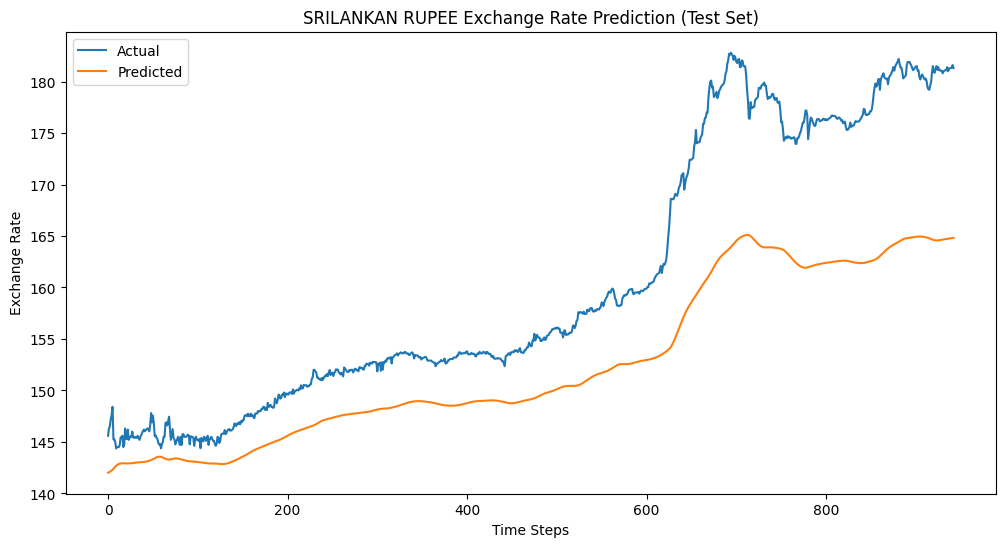

In [90]:
#visualisation
plt.figure(figsize=(12,6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{selected_option} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [91]:
#not that good of a model
#even though the metrics are good for training and validation dataset, the scores were high for the testing dataset 
#the predicted scores were lower than the actual model - deviates a lot at larger time steps
#use a different model 

In [92]:
#turning it into a function for use on other currencies 

def lstm_model(
    df, 
    currency_col, 
    validation_split=0.1, 
    n_input=60, 
    learning_rate=0.0001,
    epochs=50,
    patience=2
):
    ''' 
    Parameters:
    -----------
    df : pandas DataFrame
        Preprocessed dataframe with datetime index
    currency_col : str
        Column name of the currency to predict
    validation_split : float
        Percentage to split from training for validation (default: 10%)
    n_input : int
        Number of time steps to look back (window size)
    learning_rate : float
        Learning rate for Adam optimizer
    epochs : int
        Maximum number of training epochs
    patience : int
        Patience for early stopping
    
    Returns:
    --------
    Dictionary containing:
        - model: trained LSTM model
        - predictions: test set predictions
        - metrics: MAE, RMSE, MAPE for train/val/test
        - scaler: fitted MinMaxScaler
        - y_test_true: actual test values
        - y_test_pred: predicted test values
    '''

    # 1. Extract the currency series
    series = df[currency_col]

    # 2. Train/Validation/Test split
    total_rows = len(series)
    train_end = int(0.7 * total_rows)
    val_end = int(0.8 * total_rows)

    # Data split: train=70%, val=10%, test=20%
    train_series = series.iloc[0:train_end]
    val_series = series.iloc[train_end:val_end]
    test_series = series.iloc[val_end:]

    # 3. Scale the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    
    train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1))
    val_scaled = scaler.transform(val_series.values.reshape(-1, 1))
    test_scaled = scaler.transform(test_series.values.reshape(-1, 1))

    # 4. Create sequences function
    def Sequential_Input_LSTM(scaled_df, window):
        X = []
        y = []
        
        for i in range(len(scaled_df) - window):
            row = [a for a in scaled_df[i:i+window]]
            X.append(row)
            label = scaled_df[i + window]
            y.append(label)
        
        return np.array(X), np.array(y)
    
    # 5. Prepare datasets
    X_train, y_train = Sequential_Input_LSTM(pd.Series(train_scaled.flatten()), n_input)
    X_val, y_val = Sequential_Input_LSTM(pd.Series(val_scaled.flatten()), n_input)
    X_test, y_test = Sequential_Input_LSTM(pd.Series(test_scaled.flatten()), n_input)
    
    # 6. Create TensorFlow model
    n_features = 1  # number of input variables used for prediction
    
    model = Sequential()
    model.add(InputLayer((n_input, n_features)))
    # Add two LSTM layers with 100 units each
    model.add(LSTM(100, return_sequences=True))
    model.add(LSTM(100, return_sequences=True))
    model.add(LSTM(50))  # Another LSTM layer with 50 units
    model.add(Dense(8, activation='relu'))  # Two dense/fully connected layers
    model.add(Dense(1, activation='linear'))  # Regression forecasting
    
    # 7. Set up early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=patience)
    
    # 8. Compile the model
    model.compile(
        loss=MeanSquaredError(),
        optimizer=Adam(learning_rate=learning_rate),
        metrics=[RootMeanSquaredError()]
    )
    
    # 9. Train the model
    print(f"Training LSTM model for {currency_col}...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        callbacks=[early_stop],
        verbose=1
    )
    
    # 10. Make predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # 11. Revert back to original units (inverse scaling)
    y_train_true = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_val_true = scaler.inverse_transform(y_val.reshape(-1, 1))
    y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    y_train_pred = scaler.inverse_transform(y_train_pred)
    y_val_pred = scaler.inverse_transform(y_val_pred)
    y_test_pred = scaler.inverse_transform(y_test_pred)
    
    # 12. Compute metrics function
    def compute_metrics(y_true, y_pred):
        from sklearn.metrics import mean_absolute_error, mean_squared_error
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        return mae, rmse, mape
    
    # 13. Calculate metrics for all sets
    mae_train, rmse_train, mape_train = compute_metrics(y_train_true, y_train_pred)
    mae_val, rmse_val, mape_val = compute_metrics(y_val_true, y_val_pred)
    mae_test, rmse_test, mape_test = compute_metrics(y_test_true, y_test_pred)
    
    # 14. Print metrics
    print("\n" + "="*50)
    print(f"LSTM RESULTS FOR {currency_col}")
    print("="*50)
    print("Train Metrics:  MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(
        mae_train, rmse_train, mape_train))
    print("Val Metrics:    MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(
        mae_val, rmse_val, mape_val))
    print("Test Metrics:   MAE: {:.4f}, RMSE: {:.4f}, MAPE: {:.2f}%".format(
        mae_test, rmse_test, mape_test))
    
    # 15. Return all results in a dictionary
    return {
        'currency': currency_col,
        'model': model,
        'scaler': scaler,
        'history': history,
        'predictions': {
            'train': (y_train_true, y_train_pred),
            'val': (y_val_true, y_val_pred),
            'test': (y_test_true, y_test_pred)
        },
        'metrics': {
            'train': {'MAE': mae_train, 'RMSE': rmse_train, 'MAPE': mape_train},
            'val': {'MAE': mae_val, 'RMSE': rmse_val, 'MAPE': mape_val},
            'test': {'MAE': mae_test, 'RMSE': rmse_test, 'MAPE': mape_test}
        },
        'data_splits': {
            'train_size': len(train_series),
            'val_size': len(val_series),
            'test_size': len(test_series),
            'train_series': train_series,
            'val_series': val_series,
            'test_series': test_series
        }
    }
    

Training LSTM model for EURO AREA - EURO/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - loss: 0.0290 - root_mean_squared_error: 0.1703 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0327
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0011 - root_mean_squared_error: 0.0338 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0351
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0011 - root_mean_squared_error: 0.0330 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0324
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0011 - root_mean_squared_error: 0.0327 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0364
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 9.9658e-04 - root_mean_squared_error: 0.0316 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0329
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

LSTM RESULTS FOR EURO ARE

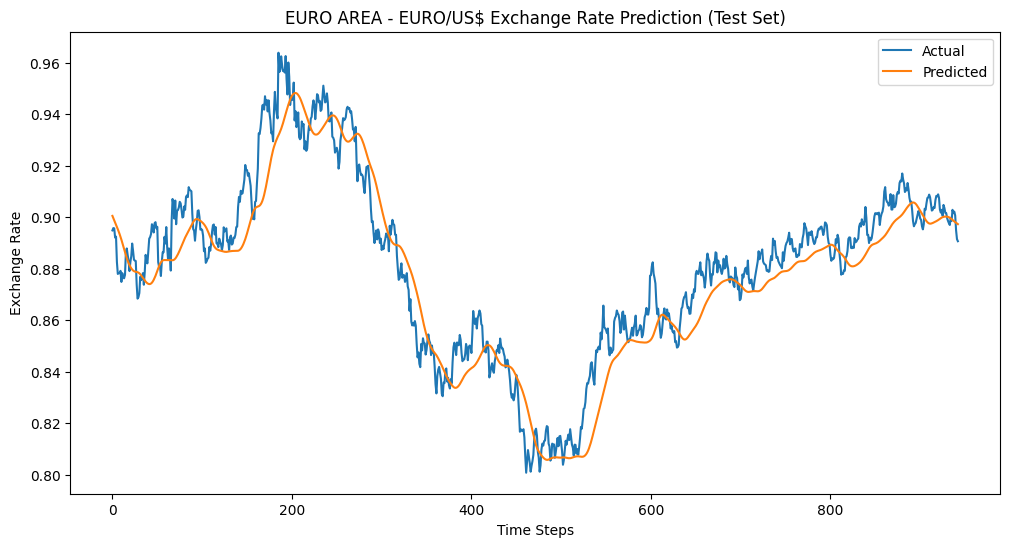

In [93]:
#Euros
currency_to_predict = 'EURO AREA - EURO/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for SRI LANKA - SRI LANKAN RUPEE/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 111ms/step - loss: 0.1159 - root_mean_squared_error: 0.3404 - val_loss: 0.0196 - val_root_mean_squared_error: 0.1399
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 8.3169e-04 - root_mean_squared_error: 0.0288 - val_loss: 0.0023 - val_root_mean_squared_error: 0.0475
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 4.6495e-04 - root_mean_squared_error: 0.0216 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0409
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 4.4267e-04 - root_mean_squared_error: 0.0210 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0359
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 4.5353e-04 - root_mean_squared_error: 0.0213 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0373
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 4.1067e-04 - root_mean_squared_error: 0.0203 - val_loss: 0

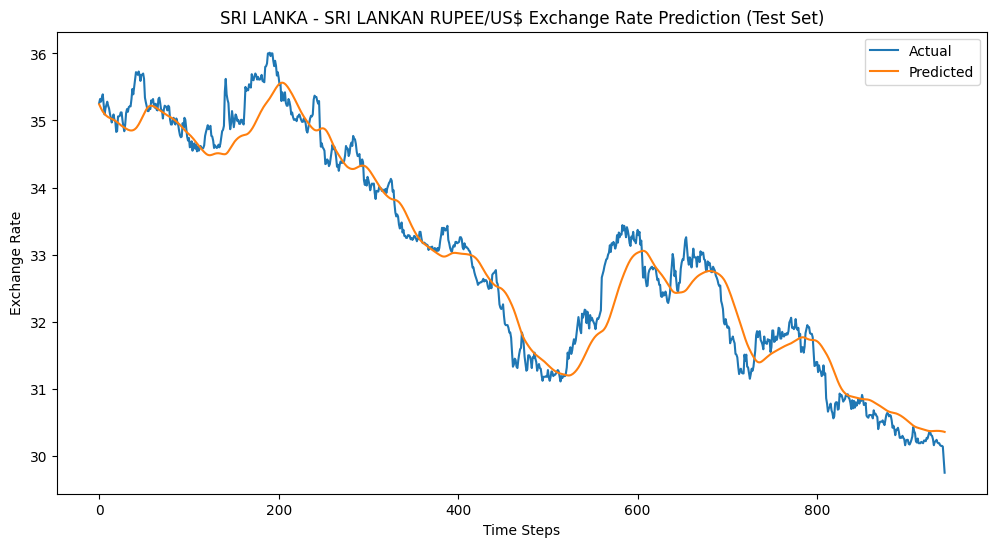

In [116]:
#Sri Lanka 
currency_to_predict = 'SRI LANKA - SRI LANKAN RUPEE/US$'
slr_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = slr_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for AUSTRALIA - AUSTRALIAN DOLLAR/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - loss: 0.0214 - root_mean_squared_error: 0.1463 - val_loss: 5.2080e-04 - val_root_mean_squared_error: 0.0228
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0012 - root_mean_squared_error: 0.0346 - val_loss: 7.5374e-04 - val_root_mean_squared_error: 0.0275
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0012 - root_mean_squared_error: 0.0341 - val_loss: 7.2064e-04 - val_root_mean_squared_error: 0.0268
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

LSTM RESULTS FOR AUSTRALIA - AUSTRALIAN DOLLAR/US$
Train Metrics:  MAE: 0.0282, RMSE: 0.0391, MAPE: 2.09%
Val Metrics:    MAE: 0.0248, RMSE: 0.0313, MAPE: 1.97%
Test Metrics:   MAE: 0.0207, RMSE: 0.0255, MAPE: 1.53%


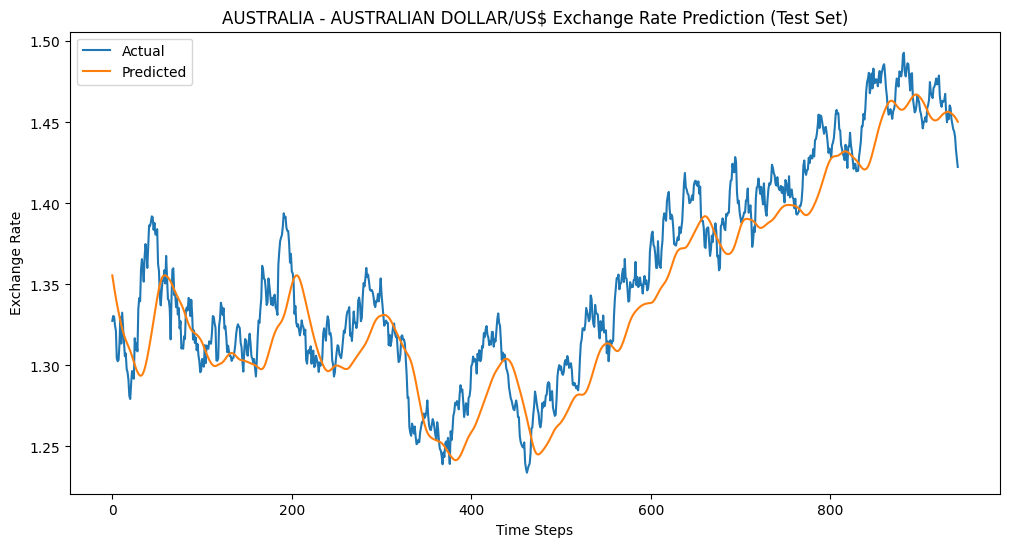

In [94]:
#Aus
currency_to_predict = 'AUSTRALIA - AUSTRALIAN DOLLAR/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for NEW ZEALAND - NEW ZELAND DOLLAR/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - loss: 0.0300 - root_mean_squared_error: 0.1732 - val_loss: 8.0984e-04 - val_root_mean_squared_error: 0.0285
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0013 - root_mean_squared_error: 0.0356 - val_loss: 6.5325e-04 - val_root_mean_squared_error: 0.0256
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0012 - root_mean_squared_error: 0.0346 - val_loss: 6.2210e-04 - val_root_mean_squared_error: 0.0249
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0011 - root_mean_squared_error: 0.0339 - val_loss: 5.6132e-04 - val_root_mean_squared_error: 0.0237
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.0011 - root_mean_squared_error: 0.0331 - val_loss: 5.3784e-04 - val_root_mean_squared_error: 0.0232
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0011 - root_mean_squared_error: 0.0328 - val_loss: 5

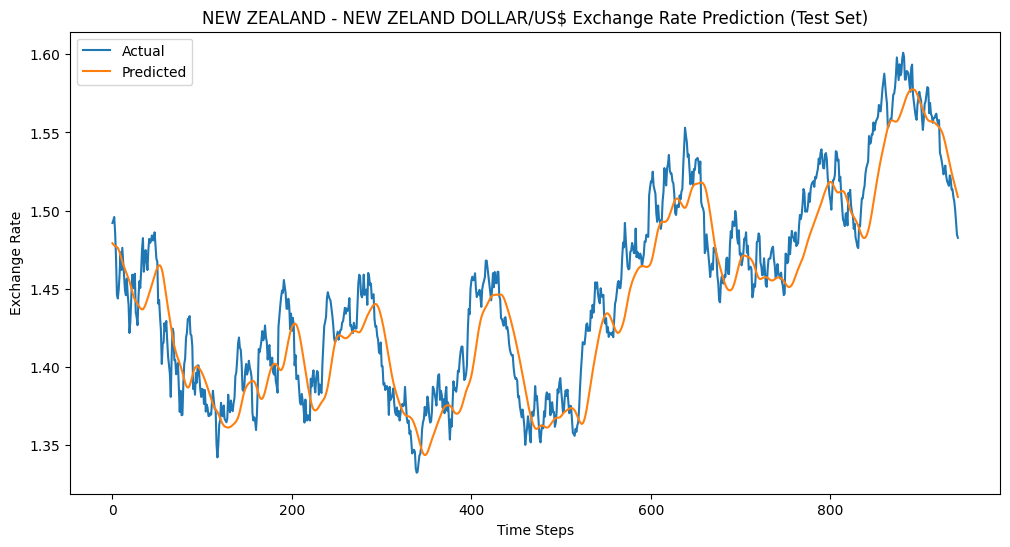

In [95]:
#NZ
currency_to_predict = 'NEW ZEALAND - NEW ZELAND DOLLAR/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for UNITED KINGDOM - UNITED KINGDOM POUND/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - loss: 0.1703 - root_mean_squared_error: 0.4127 - val_loss: 0.0019 - val_root_mean_squared_error: 0.0439
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0031 - root_mean_squared_error: 0.0556 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0380
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0023 - root_mean_squared_error: 0.0483 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0364
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - loss: 0.0022 - root_mean_squared_error: 0.0471 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0345
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0021 - root_mean_squared_error: 0.0457 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0339
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0019 - root_mean_squared_error: 0.0440 - val_loss: 0.0012 - val

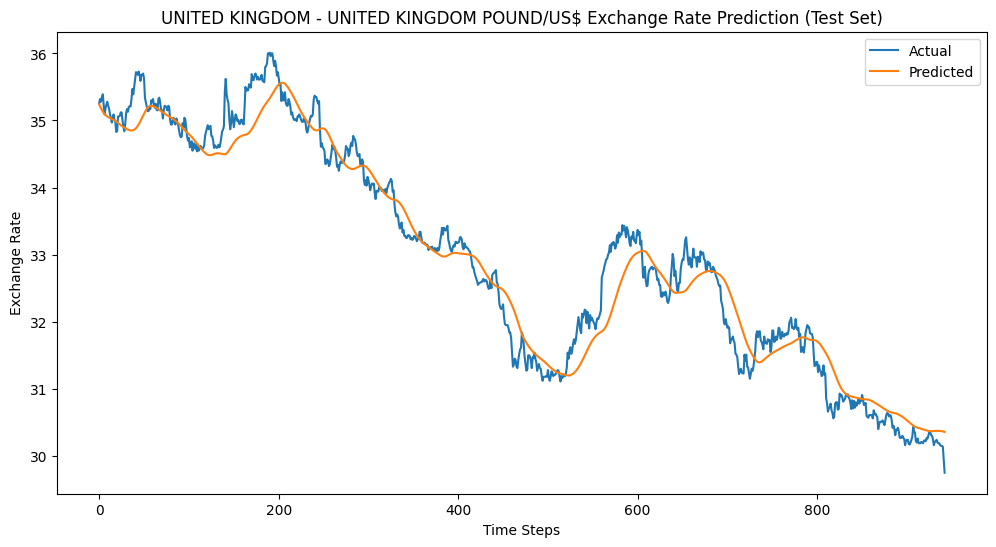

In [117]:
#UK
currency_to_predict = 'UNITED KINGDOM - UNITED KINGDOM POUND/US$'
uk_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = uk_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for BRAZIL - REAL/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - loss: 0.0153 - root_mean_squared_error: 0.1236 - val_loss: 0.0042 - val_root_mean_squared_error: 0.0651
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0014 - root_mean_squared_error: 0.0368 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0539
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0012 - root_mean_squared_error: 0.0352 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0618
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0011 - root_mean_squared_error: 0.0337 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0535
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0010 - root_mean_squared_error: 0.0322 - val_loss: 0.0020 - val_root_mean_squared_error: 0.0450
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 8.9782e-04 - root_mean_squared_error: 0.0300 - val_loss: 0.0017 - val_root_mean_squared_erro

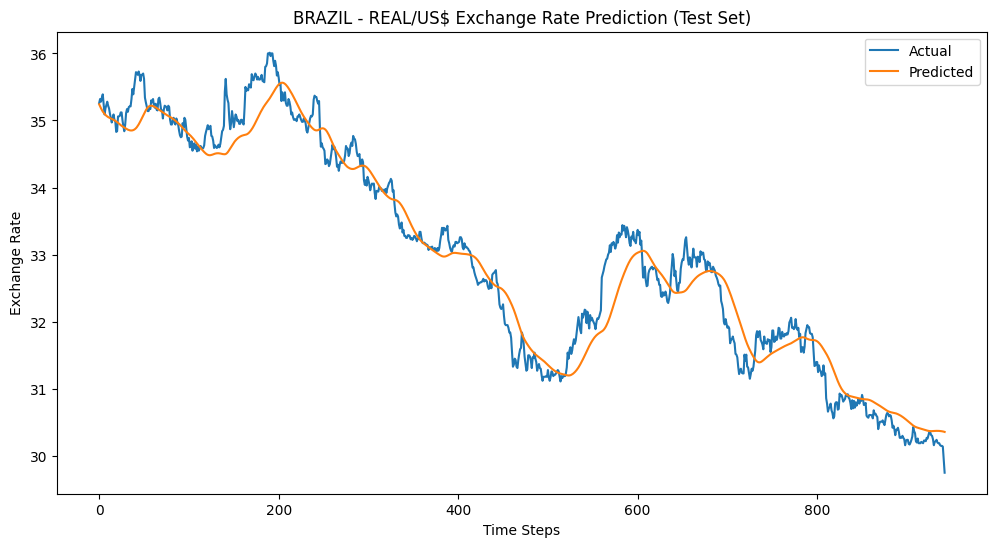

In [118]:
#BRZ
currency_to_predict = 'BRAZIL - REAL/US$'
brz_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = brz_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for CANADA - CANADIAN DOLLAR/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - loss: 0.0475 - root_mean_squared_error: 0.2180 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0365
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0011 - root_mean_squared_error: 0.0339 - val_loss: 0.0017 - val_root_mean_squared_error: 0.0413
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0011 - root_mean_squared_error: 0.0332 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0427
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

LSTM RESULTS FOR CANADA - CANADIAN DOLLAR/US$
Train Metrics:  MAE: 0.0171, RMSE: 0.0230, MAPE: 1.43%
Val Metrics:    MAE: 0.0236, RMSE: 0.0297, MAPE: 1.92%
Test Metrics:   MAE: 0.0178, RMSE: 0.0214, MAPE: 1.36%


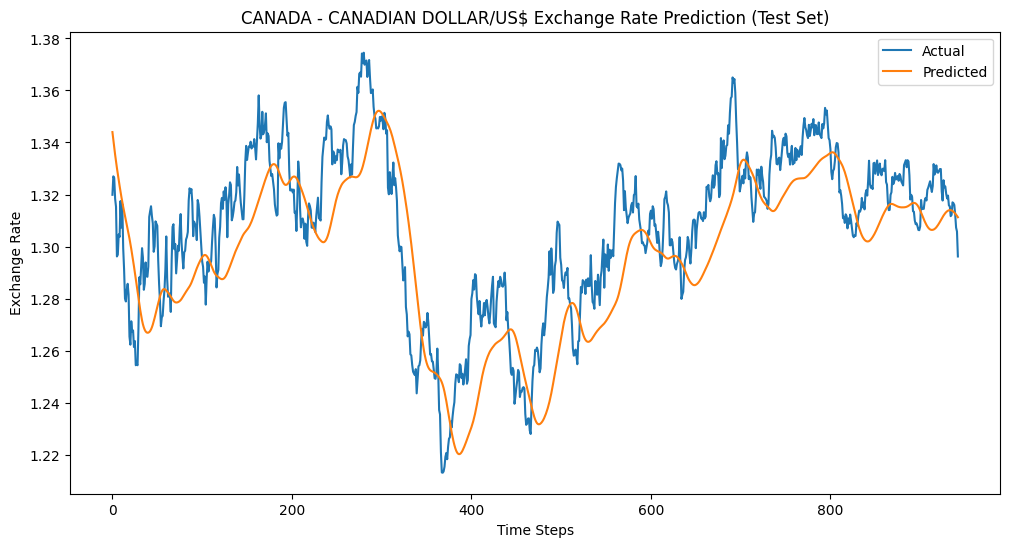

In [98]:
#CND
currency_to_predict = 'CANADA - CANADIAN DOLLAR/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for CHINA - YUAN/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - loss: 0.0795 - root_mean_squared_error: 0.2820 - val_loss: 0.0020 - val_root_mean_squared_error: 0.0452
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 5.6410e-04 - root_mean_squared_error: 0.0238 - val_loss: 3.7676e-04 - val_root_mean_squared_error: 0.0194
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 2.0254e-04 - root_mean_squared_error: 0.0142 - val_loss: 3.6709e-04 - val_root_mean_squared_error: 0.0192
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 1.9262e-04 - root_mean_squared_error: 0.0139 - val_loss: 3.6493e-04 - val_root_mean_squared_error: 0.0191
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - loss: 1.8800e-04 - root_mean_squared_error: 0.0137 - val_loss: 3.6503e-04 - val_root_mean_squared_error: 0.0191
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - loss: 1.7981e-04 - root_mean_squared_error: 0.0134 - val_loss: 

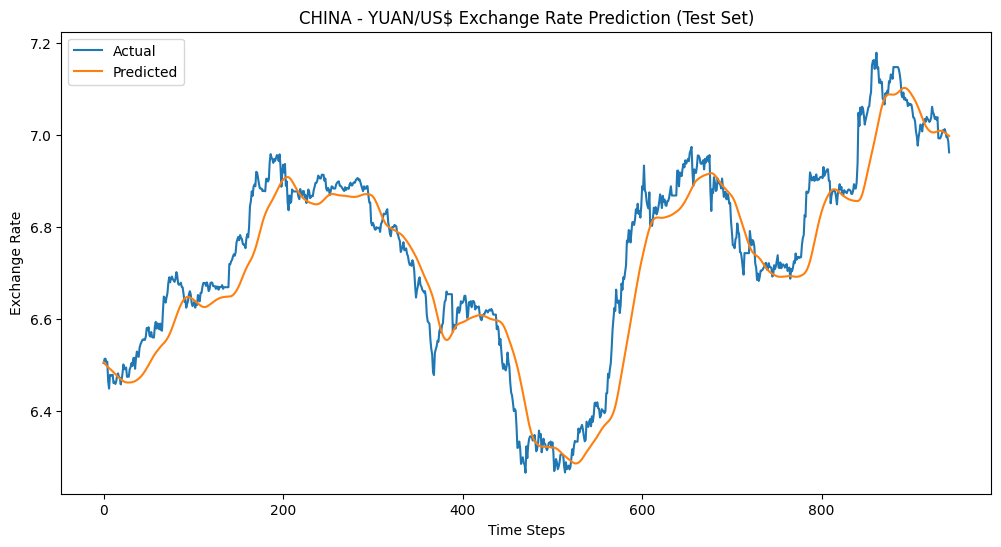

In [99]:
#CNY
currency_to_predict = 'CHINA - YUAN/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for HONG KONG - HONG KONG DOLLAR/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 111ms/step - loss: 0.0584 - root_mean_squared_error: 0.2418 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0331
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 125ms/step - loss: 0.0043 - root_mean_squared_error: 0.0655 - val_loss: 6.8497e-04 - val_root_mean_squared_error: 0.0262
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - loss: 0.0038 - root_mean_squared_error: 0.0620 - val_loss: 5.7082e-04 - val_root_mean_squared_error: 0.0239
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0034 - root_mean_squared_error: 0.0586 - val_loss: 9.6914e-04 - val_root_mean_squared_error: 0.0311
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0030 - root_mean_squared_error: 0.0552 - val_loss: 7.1885e-04 - val_root_mean_squared_error: 0.0268
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/ste

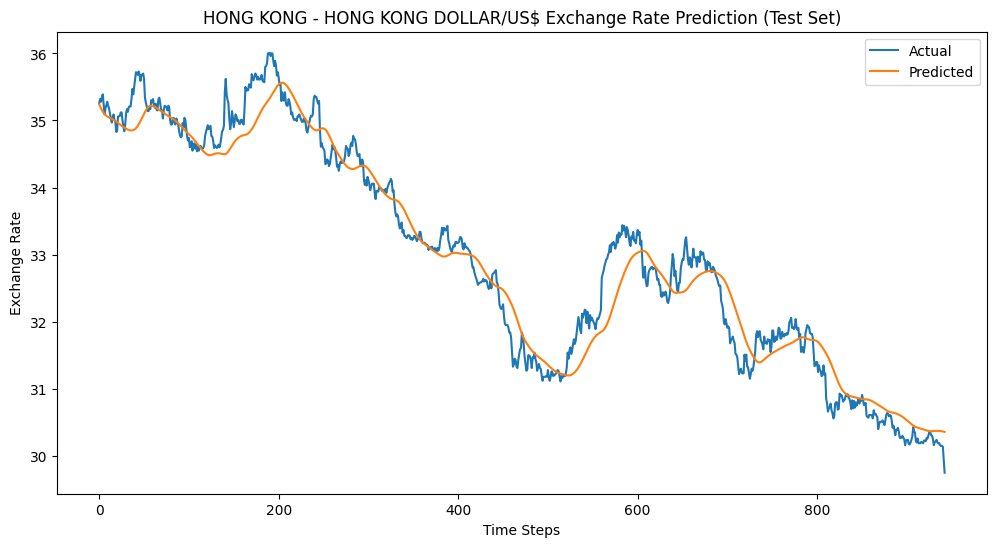

In [119]:
#HKD
currency_to_predict = 'HONG KONG - HONG KONG DOLLAR/US$'
hkd_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = hkd_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for INDIA - INDIAN RUPEE/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - loss: 0.0190 - root_mean_squared_error: 0.1379 - val_loss: 7.8290e-04 - val_root_mean_squared_error: 0.0280
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 8.4308e-04 - root_mean_squared_error: 0.0290 - val_loss: 6.8359e-04 - val_root_mean_squared_error: 0.0261
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 7.5005e-04 - root_mean_squared_error: 0.0274 - val_loss: 6.1652e-04 - val_root_mean_squared_error: 0.0248
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 6.8312e-04 - root_mean_squared_error: 0.0261 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0393
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 6.3522e-04 - root_mean_squared_error: 0.0252 - val_loss: 9.3874e-04 - val_root_mean_squared_error: 0.0306
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37m

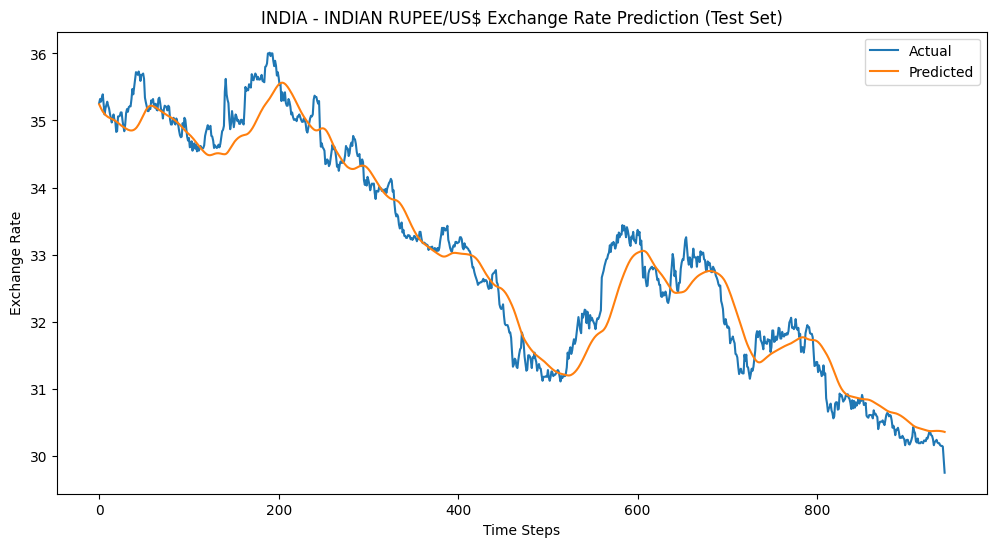

In [120]:
#IDR
currency_to_predict = 'INDIA - INDIAN RUPEE/US$'
idr_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = idr_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for KOREA - WON/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 118ms/step - loss: 0.0675 - root_mean_squared_error: 0.2598 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0318
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0025 - root_mean_squared_error: 0.0497 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0375
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - loss: 0.0022 - root_mean_squared_error: 0.0468 - val_loss: 9.4557e-04 - val_root_mean_squared_error: 0.0308
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0020 - root_mean_squared_error: 0.0447 - val_loss: 9.4672e-04 - val_root_mean_squared_error: 0.0308
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - loss: 0.0018 - root_mean_squared_error: 0.0424 - val_loss: 7.8533e-04 - val_root_mean_squared_error: 0.0280
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0016 - root_mean_squared_error: 0.0399 - val_loss: 7.4652e-04 - val_root_me

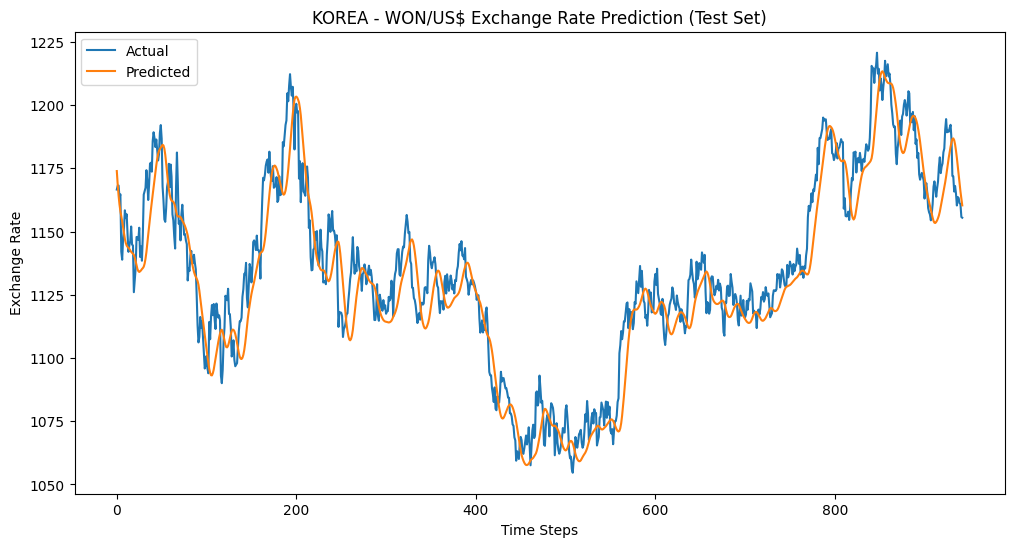

In [102]:
#KRW
currency_to_predict = 'KOREA - WON/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for MEXICO - MEXICAN PESO/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - loss: 0.0320 - root_mean_squared_error: 0.1789 - val_loss: 0.0126 - val_root_mean_squared_error: 0.1122
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0018 - root_mean_squared_error: 0.0430 - val_loss: 0.0119 - val_root_mean_squared_error: 0.1091
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 0.0017 - root_mean_squared_error: 0.0417 - val_loss: 0.0082 - val_root_mean_squared_error: 0.0905
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - loss: 0.0016 - root_mean_squared_error: 0.0404 - val_loss: 0.0080 - val_root_mean_squared_error: 0.0894
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0016 - root_mean_squared_error: 0.0398 - val_loss: 0.0067 - val_root_mean_squared_error: 0.0817
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0015 - root_mean_squared_error: 0.0385 - val_loss: 0.0070 - val_root_mean_squa

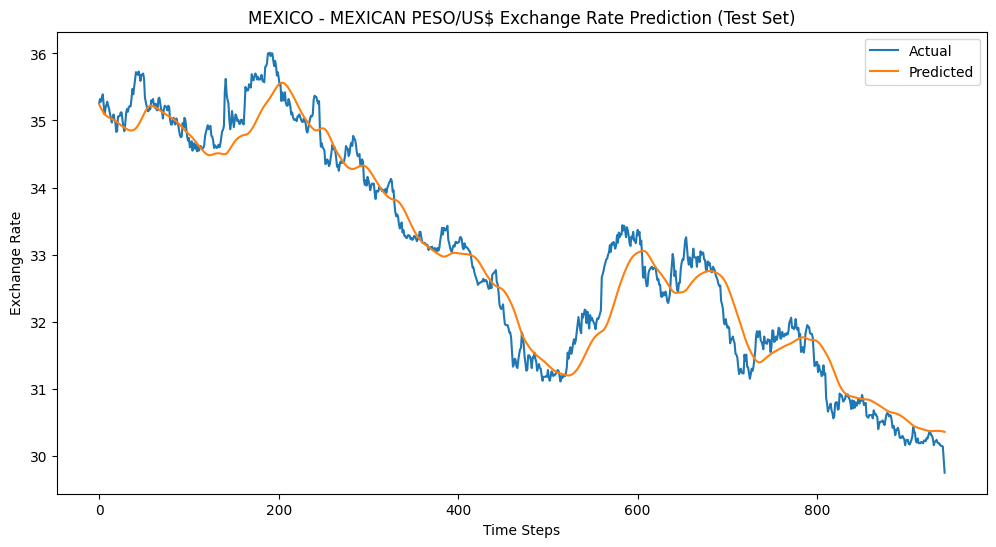

In [121]:
#MXP
currency_to_predict = 'MEXICO - MEXICAN PESO/US$'
mxp_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = mxp_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for SOUTH AFRICA - RAND/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - loss: 0.0118 - root_mean_squared_error: 0.1085 - val_loss: 0.0029 - val_root_mean_squared_error: 0.0538
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0015 - root_mean_squared_error: 0.0387 - val_loss: 0.0025 - val_root_mean_squared_error: 0.0502
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0014 - root_mean_squared_error: 0.0370 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0458
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 0.0013 - root_mean_squared_error: 0.0356 - val_loss: 0.0036 - val_root_mean_squared_error: 0.0596
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0011 - root_mean_squared_error: 0.0330 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0652
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

LSTM RESULTS FOR SOUTH AF

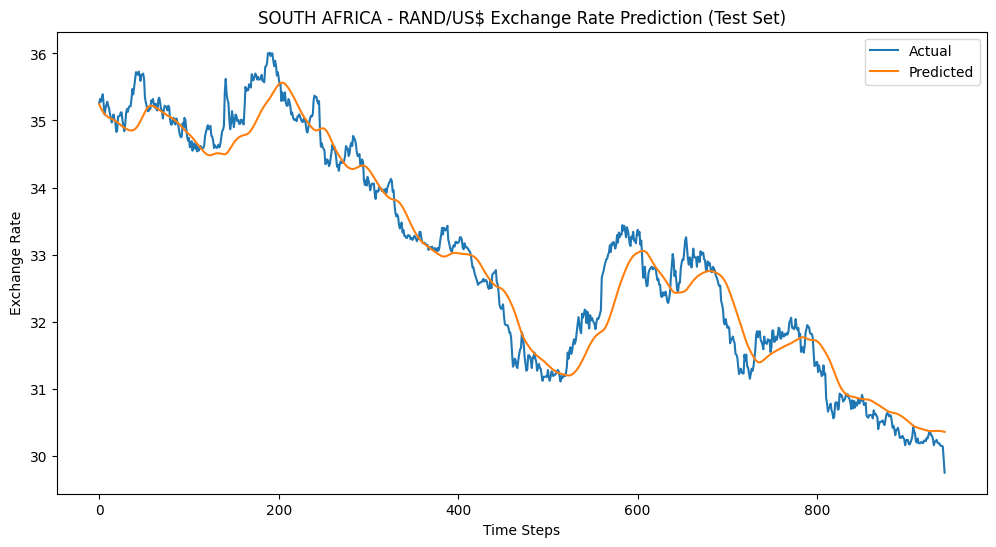

In [122]:
#SAR
currency_to_predict = 'SOUTH AFRICA - RAND/US$'
sar_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = sar_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for SINGAPORE - SINGAPORE DOLLAR/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - loss: 0.0365 - root_mean_squared_error: 0.1910 - val_loss: 9.0875e-04 - val_root_mean_squared_error: 0.0301
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 7.1421e-04 - root_mean_squared_error: 0.0267 - val_loss: 6.3246e-04 - val_root_mean_squared_error: 0.0251
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - loss: 6.2073e-04 - root_mean_squared_error: 0.0249 - val_loss: 5.7772e-04 - val_root_mean_squared_error: 0.0240
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 6.1525e-04 - root_mean_squared_error: 0.0248 - val_loss: 5.5241e-04 - val_root_mean_squared_error: 0.0235
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - loss: 6.0180e-04 - root_mean_squared_error: 0.0245 - val_loss: 5.6726e-04 - val_root_mean_squared_error: 0.0238
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 5.9532e-04 - root_mean_squared_error: 0

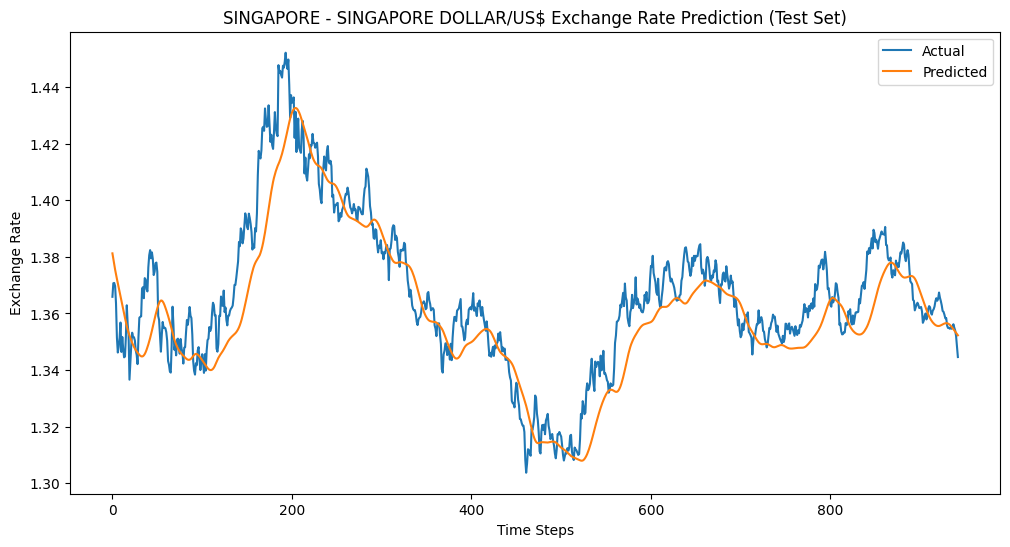

In [105]:
#SGD
currency_to_predict = 'SINGAPORE - SINGAPORE DOLLAR/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for DENMARK - DANISH KRONE/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 0.0206 - root_mean_squared_error: 0.1435 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0320
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - loss: 0.0011 - root_mean_squared_error: 0.0330 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0395
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0010 - root_mean_squared_error: 0.0321 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0338
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step

LSTM RESULTS FOR DENMARK - DANISH KRONE/US$
Train Metrics:  MAE: 0.1074, RMSE: 0.1374, MAPE: 1.74%
Val Metrics:    MAE: 0.1080, RMSE: 0.1468, MAPE: 1.67%
Test Metrics:   MAE: 0.0752, RMSE: 0.0927, MAPE: 1.14%


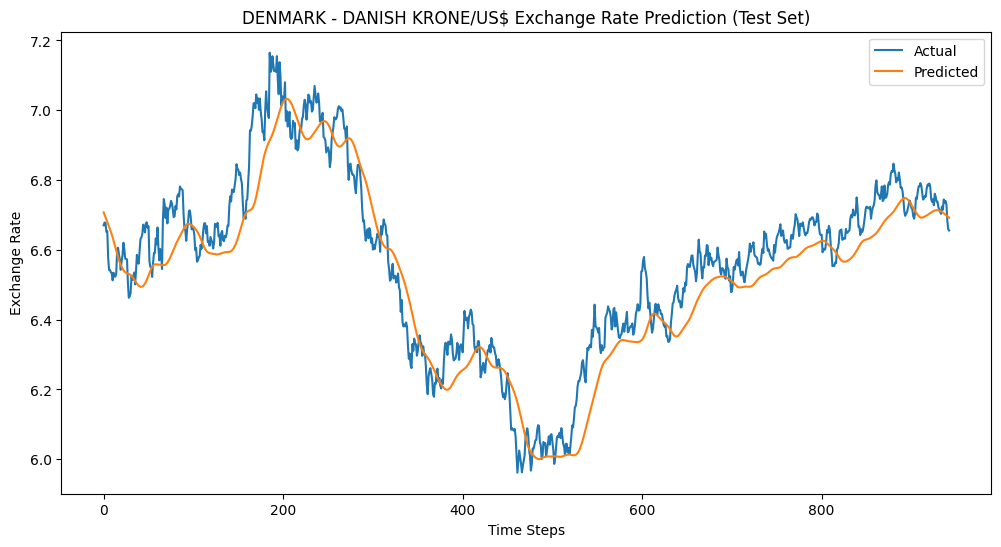

In [106]:
#DNK
currency_to_predict = 'DENMARK - DANISH KRONE/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for JAPAN - YEN/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - loss: 0.0552 - root_mean_squared_error: 0.2350 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0406
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0017 - root_mean_squared_error: 0.0415 - val_loss: 0.0015 - val_root_mean_squared_error: 0.0385
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0015 - root_mean_squared_error: 0.0382 - val_loss: 0.0016 - val_root_mean_squared_error: 0.0406
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0014 - root_mean_squared_error: 0.0374 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0371
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.0013 - root_mean_squared_error: 0.0364 - val_loss: 0.0012 - val_root_mean_squared_error: 0.0348
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0013 - root_mean_squared_error: 0.0357 - val_loss: 0.0011 - val_root_mean_squared_error: 0.03

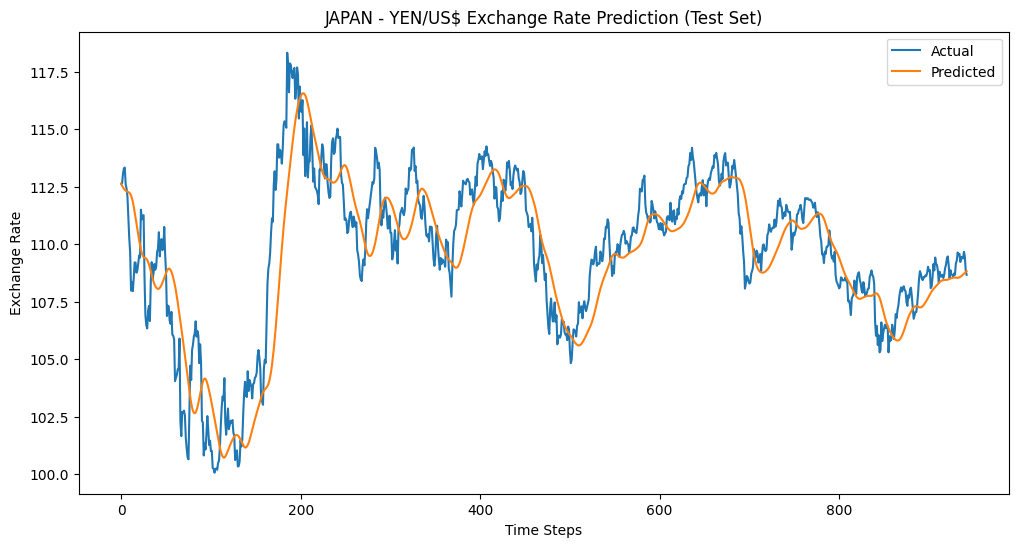

In [107]:
#JPY
currency_to_predict = 'JAPAN - YEN/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for MALAYSIA - RINGGIT/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 105ms/step - loss: 0.1291 - root_mean_squared_error: 0.3592 - val_loss: 0.0409 - val_root_mean_squared_error: 0.2023
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.0023 - root_mean_squared_error: 0.0475 - val_loss: 0.0284 - val_root_mean_squared_error: 0.1684
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.0018 - root_mean_squared_error: 0.0429 - val_loss: 0.0261 - val_root_mean_squared_error: 0.1615
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0018 - root_mean_squared_error: 0.0422 - val_loss: 0.0248 - val_root_mean_squared_error: 0.1574
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0017 - root_mean_squared_error: 0.0415 - val_loss: 0.0208 - val_root_mean_squared_error: 0.1443
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0017 - root_mean_squared_error: 0.0407 - val_loss: 0.0205 - val_root_mean_squared_err

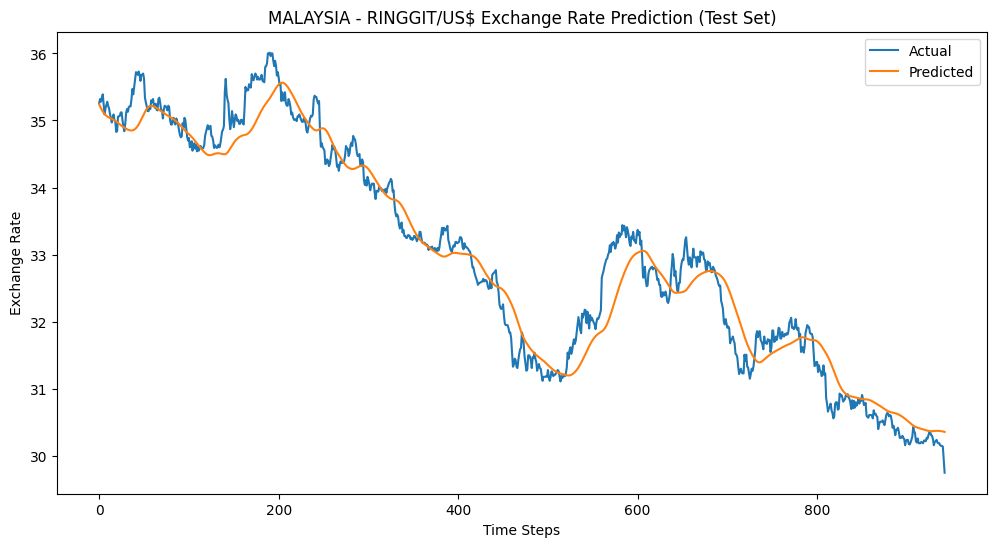

In [123]:
#MLR
currency_to_predict = 'MALAYSIA - RINGGIT/US$'
mlr_lstm = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = mlr_lstm['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for NORWAY - NORWEGIAN KRONE/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 113ms/step - loss: 0.0557 - root_mean_squared_error: 0.2361 - val_loss: 0.0020 - val_root_mean_squared_error: 0.0451
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0015 - root_mean_squared_error: 0.0392 - val_loss: 0.0028 - val_root_mean_squared_error: 0.0530
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0015 - root_mean_squared_error: 0.0383 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0456
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step

LSTM RESULTS FOR NORWAY - NORWEGIAN KRONE/US$
Train Metrics:  MAE: 0.1378, RMSE: 0.1774, MAPE: 2.10%
Val Metrics:    MAE: 0.1610, RMSE: 0.2117, MAPE: 2.16%
Test Metrics:   MAE: 0.1239, RMSE: 0.1588, MAPE: 1.49%


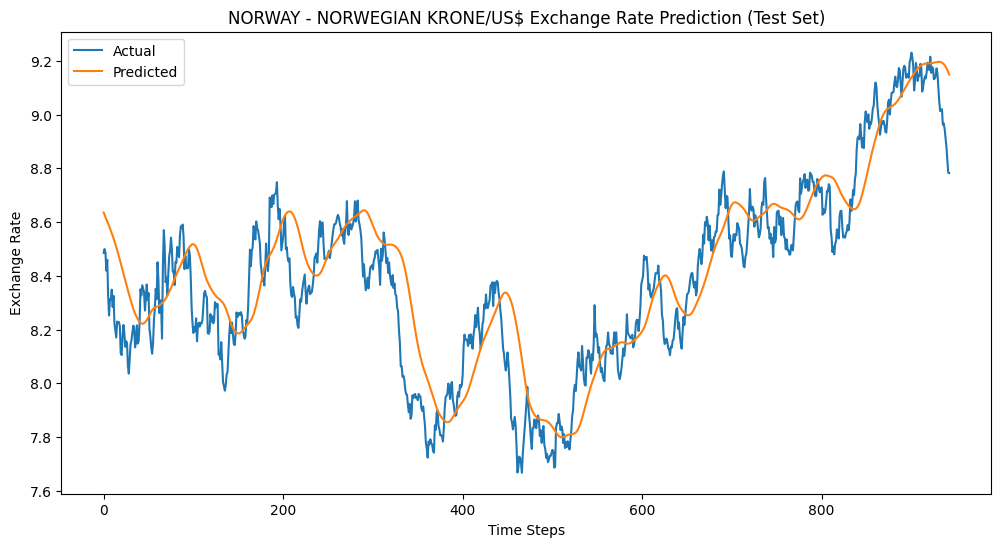

In [109]:
#NRK
currency_to_predict = 'NORWAY - NORWEGIAN KRONE/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for SWEDEN - KRONA/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - loss: 0.0205 - root_mean_squared_error: 0.1433 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0327
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 91ms/step - loss: 0.0014 - root_mean_squared_error: 0.0375 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0326
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - loss: 0.0013 - root_mean_squared_error: 0.0367 - val_loss: 9.1077e-04 - val_root_mean_squared_error: 0.0302
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 0.0013 - root_mean_squared_error: 0.0362 - val_loss: 0.0010 - val_root_mean_squared_error: 0.0322
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 0.0012 - root_mean_squared_error: 0.0351 - val_loss: 0.0013 - val_root_mean_squared_error: 0.0354
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

LSTM RESULTS FOR SWEDEN - 

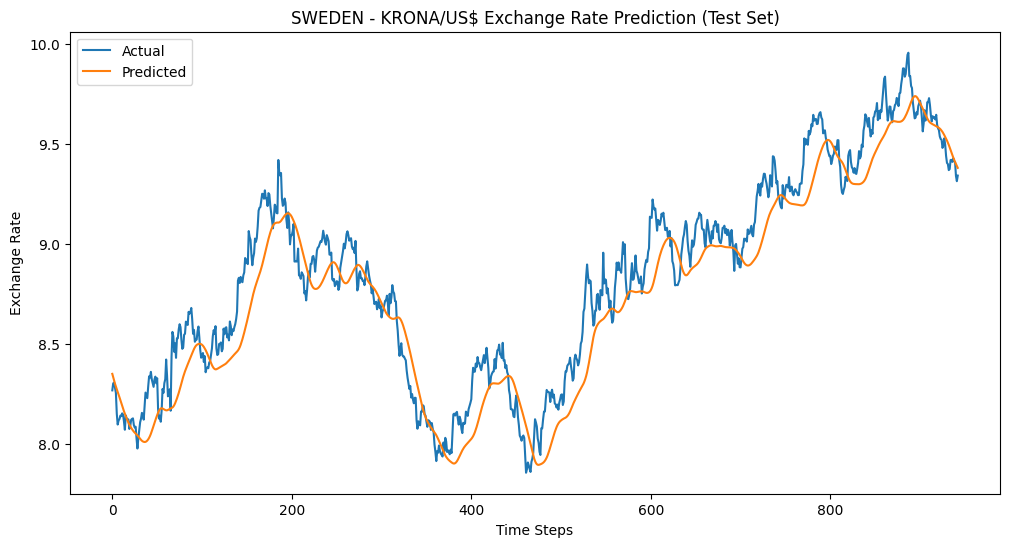

In [110]:
#SWK
currency_to_predict = 'SWEDEN - KRONA/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for SWITZERLAND - FRANC/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 39s 106ms/step - loss: 0.0991 - root_mean_squared_error: 0.3148 - val_loss: 0.0011 - val_root_mean_squared_error: 0.0327
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 0.0014 - root_mean_squared_error: 0.0369 - val_loss: 6.0330e-04 - val_root_mean_squared_error: 0.0246
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - loss: 0.0010 - root_mean_squared_error: 0.0317 - val_loss: 5.0717e-04 - val_root_mean_squared_error: 0.0225
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 9.4887e-04 - root_mean_squared_error: 0.0308 - val_loss: 4.9602e-04 - val_root_mean_squared_error: 0.0223
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 9.0947e-04 - root_mean_squared_error: 0.0302 - val_loss: 5.1248e-04 - val_root_mean_squared_error: 0.0226
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - loss: 9.0291e-04 - root_mean_squared_error: 0.0300 - val_loss: 5.

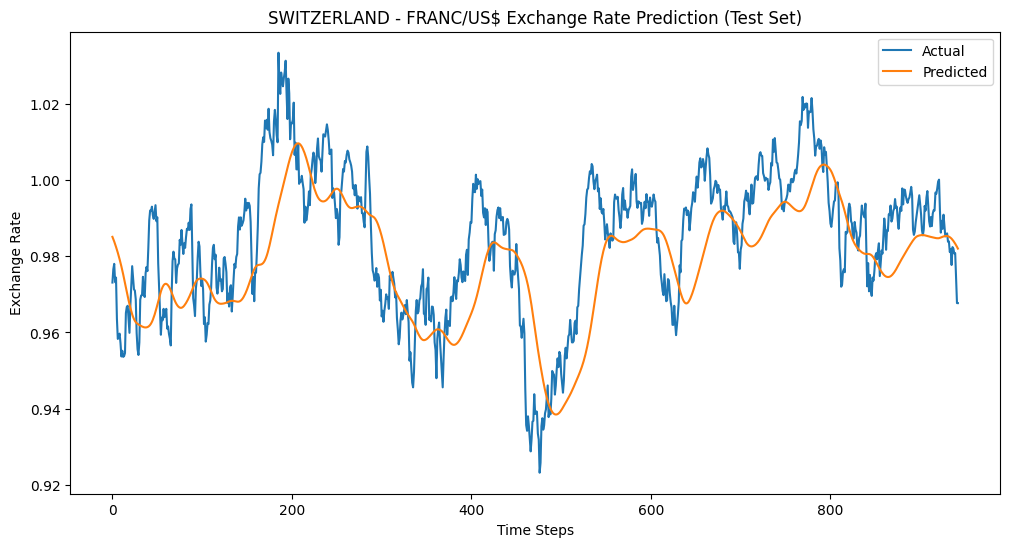

In [111]:
#SWF
currency_to_predict = 'SWITZERLAND - FRANC/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for TAIWAN - NEW TAIWAN DOLLAR/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - loss: 0.0550 - root_mean_squared_error: 0.2345 - val_loss: 0.0026 - val_root_mean_squared_error: 0.0510
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.0029 - root_mean_squared_error: 0.0539 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0470
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0025 - root_mean_squared_error: 0.0499 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0462
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - loss: 0.0024 - root_mean_squared_error: 0.0488 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0461
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - loss: 0.0022 - root_mean_squared_error: 0.0472 - val_loss: 0.0021 - val_root_mean_squared_error: 0.0455
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - loss: 0.0021 - root_mean_squared_error: 0.0458 - val_loss: 0.0019 - val_root_mean_s

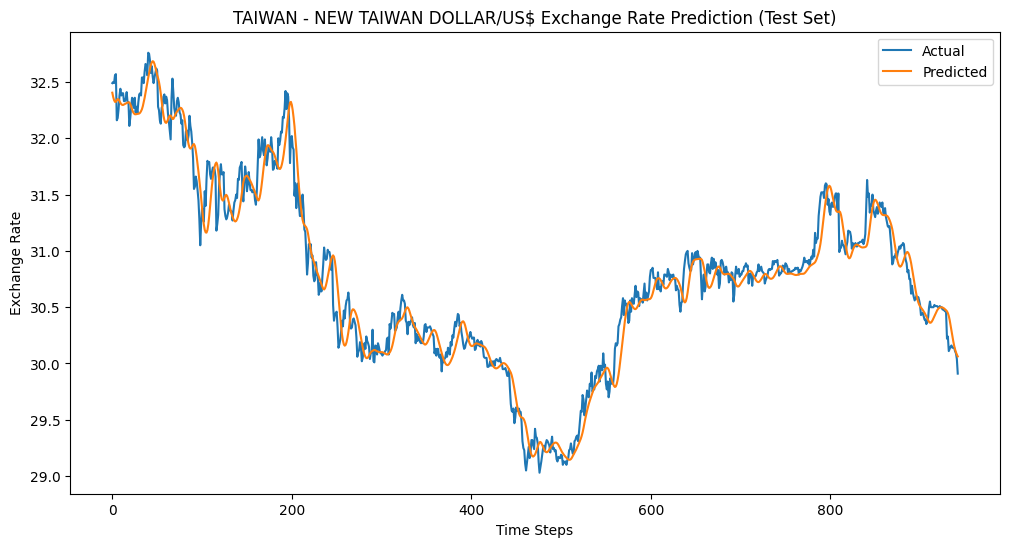

In [112]:
#TWD
currency_to_predict = 'TAIWAN - NEW TAIWAN DOLLAR/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

Training LSTM model for THAILAND - BAHT/US$...
Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - loss: 0.0405 - root_mean_squared_error: 0.2012 - val_loss: 4.8174e-04 - val_root_mean_squared_error: 0.0219
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - loss: 0.0010 - root_mean_squared_error: 0.0324 - val_loss: 6.4767e-04 - val_root_mean_squared_error: 0.0254
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 9.8651e-04 - root_mean_squared_error: 0.0314 - val_loss: 7.2791e-04 - val_root_mean_squared_error: 0.0270
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

LSTM RESULTS FOR THAILAND - BAHT/US$
Train Metrics:  MAE: 0.3971, RMSE: 0.5334, MAPE: 1.10%
Val Metrics:    MAE: 0.3516, RMSE: 0.4646, MAPE: 1.03%
Test Metrics:   MAE: 0.2677, RMSE: 0.3465, MAPE: 0.81%


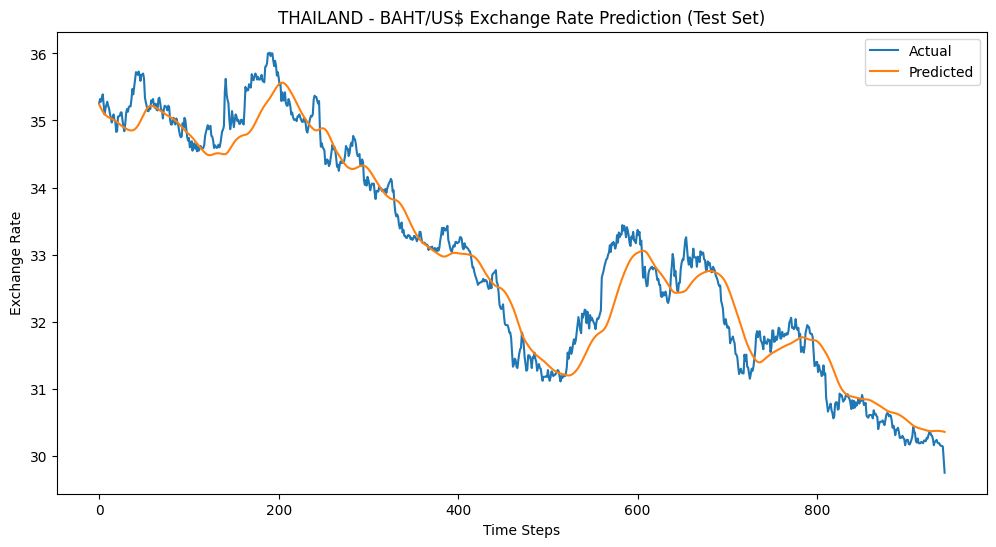

In [114]:
#Thailand
currency_to_predict = 'THAILAND - BAHT/US$'
results = lstm_model(
    df=df,
    currency_col=currency_to_predict,
    validation_split=0.1,
    n_input=60,
    learning_rate=0.0001,
    epochs=50,
    patience=2
)

y_test_true, y_test_pred = results['predictions']['test']

plt.figure(figsize=(12, 6))
plt.plot(y_test_true, label='Actual')
plt.plot(y_test_pred, label='Predicted')
plt.title(f"{currency_to_predict} Exchange Rate Prediction (Test Set)")
plt.xlabel("Time Steps")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [127]:
#saving models

import os 
from tensorflow.keras.models import save_model 

#making sure the 'models/' folder exists 
os.makedirs('models', exist_ok=True)

save_model(slr_lstm['model'], 'models/SLR_LSTM.keras') #Sri Lanka 
save_model(mlr_lstm['model'], 'models/MLR_LSTM.keras') #Malaysia
save_model(sar_lstm['model'], 'models/SAR_LSTM.keras') #South Africa
save_model(mxp_lstm['model'], 'models/MXP_LSTM.keras') #Mexico
save_model(idr_lstm['model'], 'models/IDR_LSTM.keras') #India
save_model(hkd_lstm['model'], 'models/HKD_LSTM.keras') #Hong Kong 
save_model(brz_lstm['model'], 'models/BRZ_LSTM.keras') #Brazil
save_model(uk_lstm['model'], 'models/GBP_LSTM.keras') #UK

#saving scaler with pickle
import pickle
with open("models/SLR_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(slr_lstm['scaler'], f)
with open("models/MLR_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(mlr_lstm['scaler'], f)
with open("models/SAR_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(sar_lstm['scaler'], f)
with open("models/MXP_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(mxp_lstm['scaler'], f)
with open("models/IDR_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(idr_lstm['scaler'], f)
with open("models/HKD_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(hkd_lstm['scaler'], f)
with open("models/BRZ_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(brz_lstm['scaler'], f)
with open("models/UK_LSTM_scaler.pkl", "wb") as f:
    pickle.dump(uk_lstm['scaler'], f)